# 01 — Data Understanding

## Objective

This notebook investigates the UCI Default of Credit Card Clients
dataset before machine learning is performed.

The objectives are to:

- understand the dataset structure and variables
- inspect data quality
- examine the target distribution
- identify duplicate observations
- understand categorical and repayment-status variables
- create a clean dataset for feature engineering

In [1]:
import pandas as pd
import numpy as np

## 1. Load Raw Dataset

The original UCI dataset is stored separately in `data/raw/`.
We do not modify the raw file directly.

In [2]:
raw_path = "../data/raw/default_of_credit_card_clients.csv"

df = pd.read_csv(raw_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (30000, 24)


## 2. Rename Features

The downloaded UCI feature matrix uses generic names such as `X1`,
`X2`, ..., `X23`. These are renamed to meaningful financial and
demographic names using the UCI feature definitions.

In [3]:
column_names = {
    "X1": "credit_limit",
    "X2": "gender",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",
    "X6": "repayment_sep",
    "X7": "repayment_aug",
    "X8": "repayment_july",
    "X9": "repayment_jun",
    "X10": "repayment_may",
    "X11": "repayment_apr",
    "X12": "bill_sep",
    "X13": "bill_aug",
    "X14": "bill_july",
    "X15": "bill_jun",
    "X16": "bill_may",
    "X17": "bill_apr",
    "X18": "payment_sep",
    "X19": "payment_aug",
    "X20": "payment_july",
    "X21": "payment_jun",
    "X22": "payment_may",
    "X23": "payment_apr"
}

df = df.rename(columns=column_names)

df.head()

,credit_limit,gender,education,marital_status,age,repayment_sep,repayment_aug,repayment_july,repayment_jun,repayment_may,...,bill_jun,bill_may,bill_apr,payment_sep,payment_aug,payment_july,payment_jun,payment_may,payment_apr,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Dataset Structure

We inspect the dimensions, column names, data types, and memory
usage before performing any cleaning.

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
df.info()

Shape: (30000, 24)

Columns:
['credit_limit', 'gender', 'education', 'marital_status', 'age', 'repayment_sep', 'repayment_aug', 'repayment_july', 'repayment_jun', 'repayment_may', 'repayment_apr', 'bill_sep', 'bill_aug', 'bill_july', 'bill_jun', 'bill_may', 'bill_apr', 'payment_sep', 'payment_aug', 'payment_july', 'payment_jun', 'payment_may', 'payment_apr', 'default']

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   credit_limit    30000 non-null  int64
 1   gender          30000 non-null  int64
 2   education       30000 non-null  int64
 3   marital_status  30000 non-null  int64
 4   age             30000 non-null  int64
 5   repayment_sep   30000 non-null  int64
 6   repayment_aug   30000 non-null  int64
 7   repayment_july  30000 non-null  int64
 8   repayment_jun   30000 non-null  int64
 9   repayment_may   30000 non-null  int64
 

## 4. Missing Values

The dataset is checked for missing observations before modeling.

In [5]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


## 5. Duplicate Records

Exact duplicate rows are investigated. A duplicate is considered
an exact duplicate when all features and the target are identical.

In [6]:
duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 35


In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Shape after duplicate removal: (29965, 24)
Remaining duplicates: 0


### Data-quality decision

Thirty-five exact duplicate observations were identified and removed.
Because all feature values and the target were identical, retaining the
duplicates would unnecessarily give those observations additional
weight during model training.

## 6. Target Distribution

The target variable `default` indicates whether the customer defaulted
on the following month's payment.

We examine the class distribution because default prediction is an
imbalanced classification problem.

In [8]:
target_counts = df["default"].value_counts()

print(target_counts)

default
0    23335
1     6630
Name: count, dtype: int64


In [9]:
target_percent = df["default"].value_counts(normalize=True) * 100

print(target_percent.round(2))

default
0    77.87
1    22.13
Name: proportion, dtype: float64


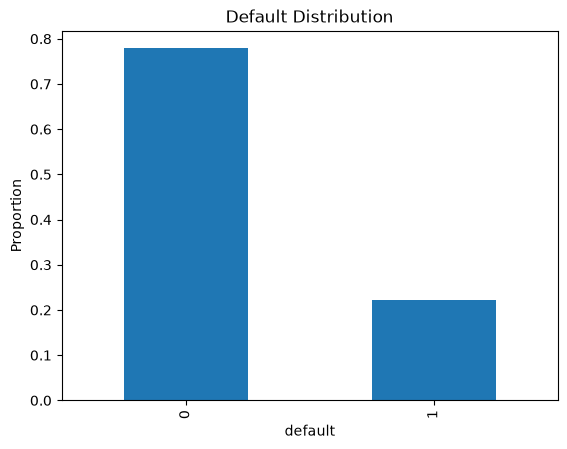

In [10]:
df["default"].value_counts(normalize=True).plot(
    kind="bar",
    title="Default Distribution",
    ylabel="Proportion"
);

## 7. Categorical Variables

Several variables are represented using numeric codes but are
categorical rather than continuous numerical measurements.

In [11]:
for col in ["gender", "education", "marital_status"]:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


gender
gender
1    11874
2    18091
Name: count, dtype: int64

education
education
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64

marital_status
marital_status
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64


## 8. Repayment Status Variables

The repayment-status variables describe the customer's repayment
behavior over six months.

The values are coded according to the UCI dataset documentation.
They include non-delay states and increasing levels of payment delay.

In [12]:
repayment_cols = [
    "repayment_sep",
    "repayment_aug",
    "repayment_july",
    "repayment_jun",
    "repayment_may",
    "repayment_apr"
]

for col in repayment_cols:
    print(f"{col}: {sorted(df[col].unique())}")

repayment_sep: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
repayment_aug: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
repayment_july: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
repayment_jun: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
repayment_may: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
repayment_apr: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## 9. Financial Variables

Credit limits, statement bills, and previous payment amounts are
examined to understand their ranges and distributions before feature
engineering.

In [14]:
bill_cols = [
    "bill_sep",
    "bill_aug",
    "bill_july",
    "bill_jun",
    "bill_may",
    "bill_apr"
]

payment_cols = [
    "payment_sep",
    "payment_aug",
    "payment_july",
    "payment_jun",
    "payment_may",
    "payment_apr"
]

display(df[["credit_limit", "age"]].describe().T)
display(df[bill_cols].describe().T)
display(df[payment_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
credit_limit,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
age,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0


,count,mean,std,min,25%,50%,75%,max
bill_sep,29965.0,51283.009778,73658.132403,-165580.0,3595.0,22438.0,67260.0,964511.0
bill_aug,29965.0,49236.366294,71195.567392,-69777.0,3010.0,21295.0,64109.0,983931.0
bill_july,29965.0,47067.916069,69371.352323,-157264.0,2711.0,20135.0,60201.0,1664089.0
bill_jun,29965.0,43313.329885,64353.514373,-170000.0,2360.0,19081.0,54601.0,891586.0
bill_may,29965.0,40358.334390,60817.130623,-81334.0,1787.0,18130.0,50247.0,927171.0
bill_apr,29965.0,38917.012281,59574.147742,-339603.0,1262.0,17124.0,49252.0,961664.0


,count,mean,std,min,25%,50%,75%,max
payment_sep,29965.0,5670.099316,16571.849467,0.0,1000.0,2102.0,5008.0,873552.0
payment_aug,29965.0,5927.983180,23053.456645,0.0,850.0,2010.0,5000.0,1684259.0
payment_july,29965.0,5231.688837,17616.361124,0.0,390.0,1804.0,4512.0,896040.0
payment_jun,29965.0,4831.617454,15674.464538,0.0,300.0,1500.0,4016.0,621000.0
payment_may,29965.0,4804.897047,15286.372298,0.0,261.0,1500.0,4042.0,426529.0
payment_apr,29965.0,5221.498014,17786.976864,0.0,131.0,1500.0,4000.0,528666.0


## 10. Data Understanding Summary

Key observations:

- The original dataset contains 30,000 observations and 24 columns,
  including 23 explanatory variables and one target.
- There are no missing values.
- Thirty-five exact duplicate rows were removed.
- The target is imbalanced, with approximately 22% default cases.
- Gender, education, and marital status are coded categorical variables.
- Repayment history contains coded repayment states across six months.
- Statement bill amounts contain some negative and above-limit values,
  so derived utilization features will be created without modifying
  the original bill columns.
- Payment amounts are non-negative but highly right-skewed.

## 11. Save Clean Dataset

The cleaned dataset is saved separately from the raw dataset.
This file becomes the input for the feature-engineering notebook.

In [15]:
clean_path = "../data/processed/credit_risk_clean.csv"

df.to_csv(clean_path, index=False)

print(f"Clean dataset saved to: {clean_path}")
print(f"Shape: {df.shape}")

Clean dataset saved to: ../data/processed/credit_risk_clean.csv
Shape: (29965, 24)
